In [1]:


library("misha")
library("misha.ext")
library("zoo")
library("tglkmeans")
library("misha.ext")
library("data.table")
library(tidyverse)
library(tgstat)
library(prego)
library(tgutil)
#gdb.reload()

#gdb.reload()
options(gmax.data.size = 1e10)
options(gmultitasking = FALSE)


library(here)
here()


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



Attaching package: ‘data.table’


The following objects are masked from ‘package:zoo’:

    yearmon, yearqtr


Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::

[1] "/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_raw"

In [2]:
gsetroot(paste0(here(),'/data/hg19/'))

In [3]:
setwd(here())

In [4]:
gdb.reload()
#source(paste0(here(),'/code/ebpcg_domains_hg19.r'))
#source(paste0(here(),'/code/ebpcg_model_hg19.r'))
source(paste0(here(),'/code/hgpcg_domains_hg19.r'))
source(paste0(here(),'/code/fig_fun.r'))
source(paste0(here(),'/code/seq2epi_utils.r'))

In [5]:
mod = hpcg_init()

In [23]:
gtrack.ls('ATACseq')

[1] "jk.H1_ATACseq_dense_regcap"          
[2] "meers_mol_cell_2019.H1_ATACseq_dense"

In [6]:
gen_k4_vt(mod)
gen_k27_vt(mod)
  



cgd = mod$cgdom_ann
cgd_data <- gextract(c("h1_1", 'h1_1_k4'), intervals = cgd, iterator = cgd) %>% arrange(intervalID) %>% 
    mutate(
        h1_cnt_k4 = h1_1_k4/(end - start) * 300, 
        h1_cnt = h1_1/(end - start) * 300
    )

cgd <- cgd %>% 
    mutate(
        h1_k4_sum = cgd_data$h1_cnt_k4,
        h1_k27_sum = cgd_data$h1_cnt,
        l10_h1_k4_sum = log2(10 + h1_k4_sum),
        l10_h1_k27_sum = log2(10 + h1_k27_sum)
    )

head(cgd)

[1] "h1_1_k4"

resp10,n
<dbl>,<int>
0,1698
1,3639
NA,28816


Warning message:
“Removed 19461 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 19461 rows containing non-finite outside the scale range
(`stat_density()`).”


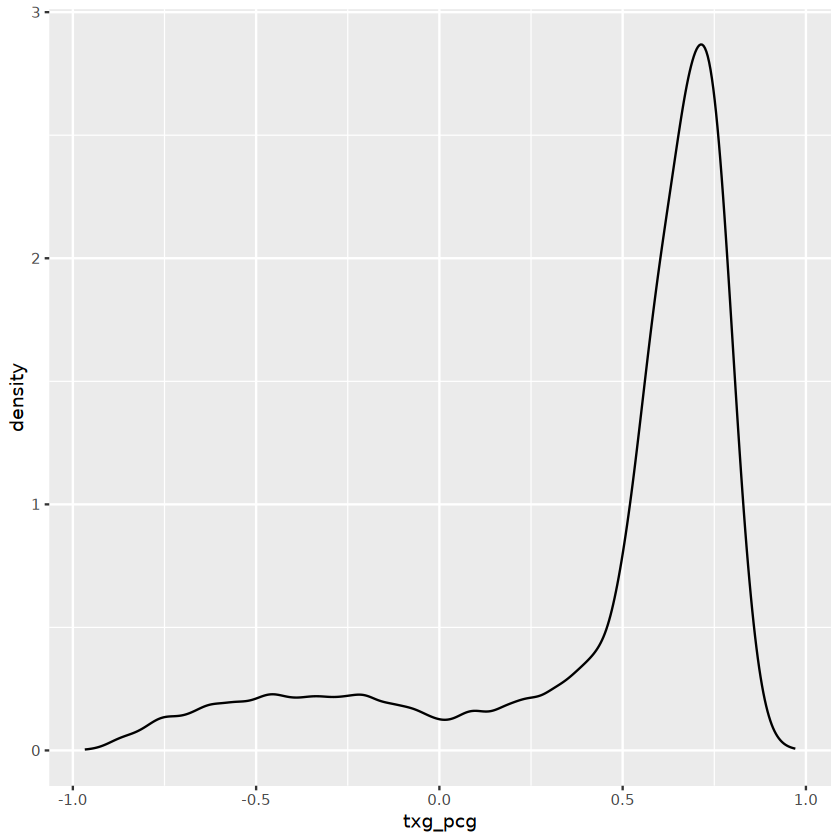

Warning message:
“Removed 12928 rows containing non-finite outside the scale range
(`stat_dense_scatter()`).”


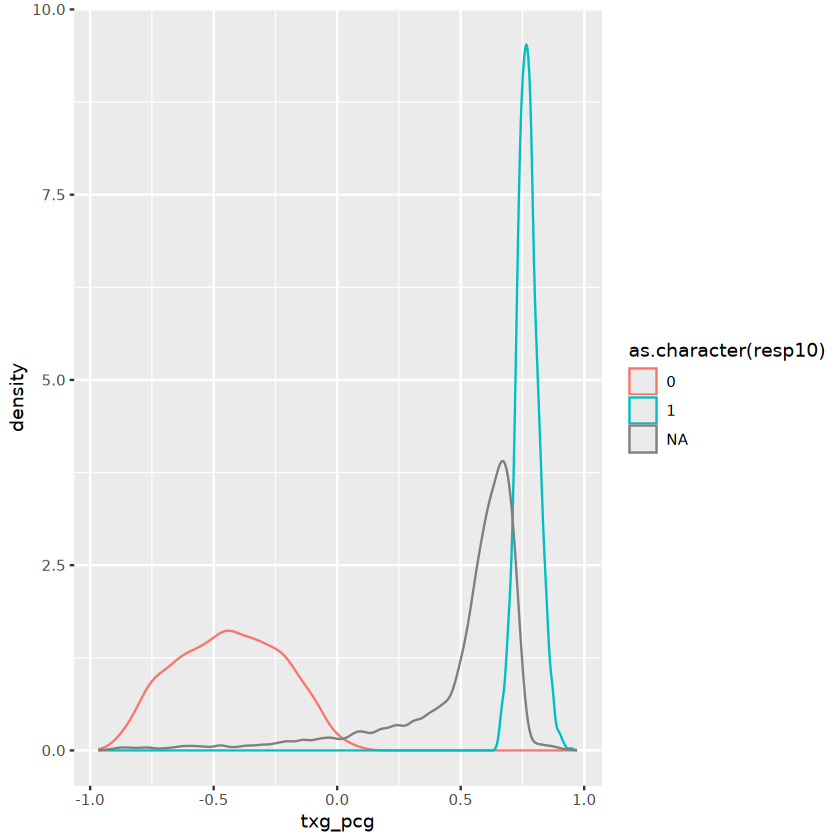

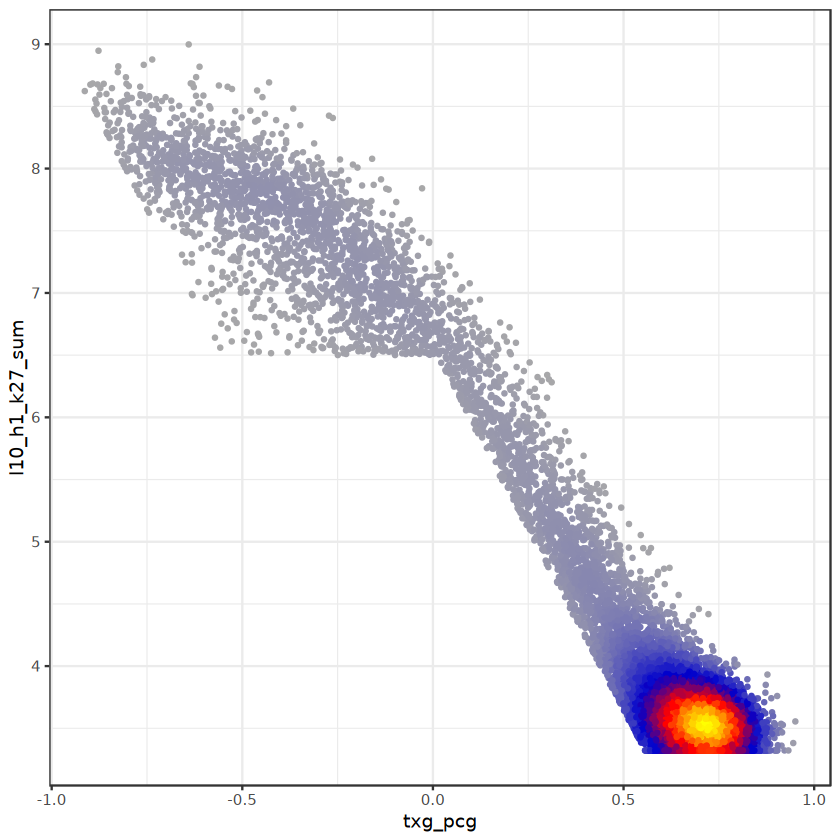

In [9]:
sps(7, 7)
txg_thresh_red = 6
txg_thresh_pink = 7
pcg_thresh_blue = 6.5
pcg_thresh_violet = 7
pcg_thresh_green = 4
cgd <- cgd %>% 
    mutate(
            pcg = l10_h1_k27_sum>=7,
        txg = l10_h1_k27_sum<=4 & l10_h1_k4_sum > 7,
        l500 = abs(end - start) > 500,
        f_out = l10_h1_k27_sum < pcg_thresh_blue & l10_h1_k4_sum < txg_thresh_red,
        txg_pcg = ifelse(f_out, NA, iceqream::norm01(l10_h1_k4_sum) - iceqream::norm01(l10_h1_k27_sum)), 
        resp10 = case_when(
            txg & l500 ~ 1,
            pcg & l500 ~ 0,            
            TRUE ~ NA_real_
        )
        
    )

cgd %>% 
    count(resp10)

cgd %>% 
    ggplot(aes(x = txg_pcg)) + geom_density()

cgd %>% 
    ggplot(aes(x = txg_pcg, color = as.character(resp10))) + geom_density()

cgd %>% 
    filter(l500) %>% 
    ggplot(aes(y = l10_h1_k27_sum, x = txg_pcg)) + geom_dense_scatter() + theme_bw() 

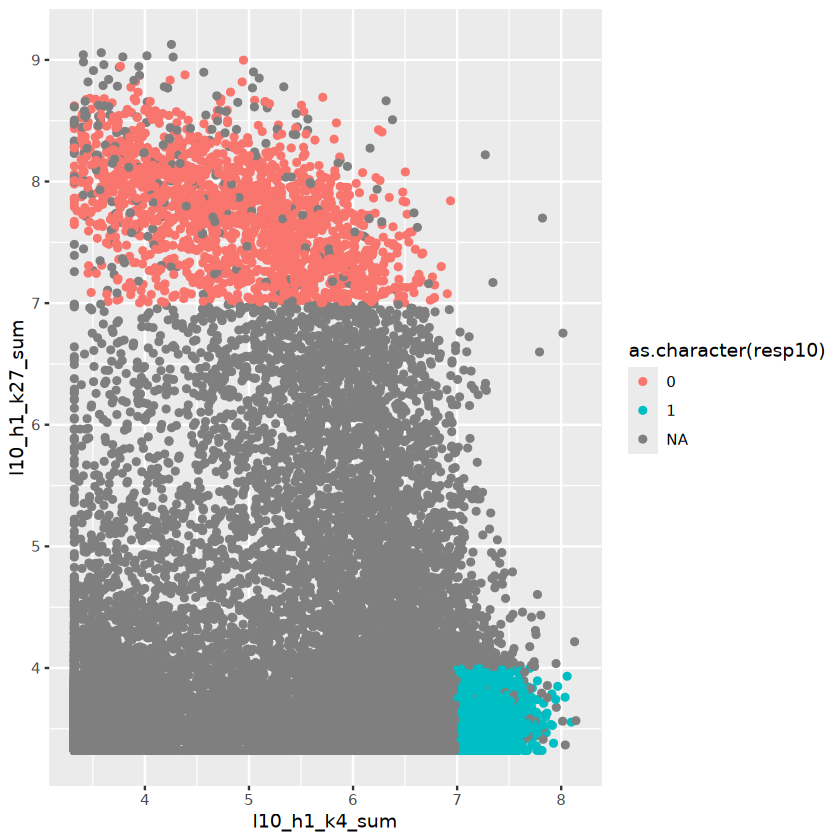

In [10]:
cgd%>% ggplot(aes(x=l10_h1_k4_sum ,y= l10_h1_k27_sum,col=as.character(resp10)))+ geom_point()

In [11]:
table(cgd$resp10)


   0    1 
1698 3639 

In [12]:
f_ambig = cgd$l10_h1_k27_sum> 4.5& cgd$l10_h1_k27_sum < 6.5

cgd$f_ambig = f_ambig

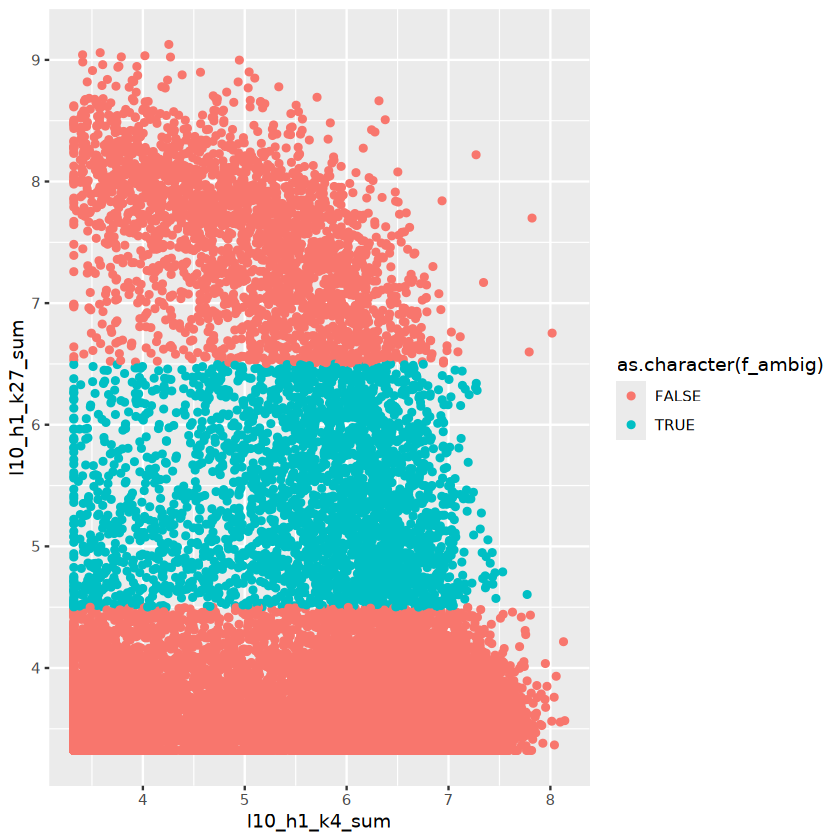

In [14]:
cgd%>% ggplot(aes(x=l10_h1_k4_sum ,y= l10_h1_k27_sum,col=as.character(f_ambig)))+ geom_point()

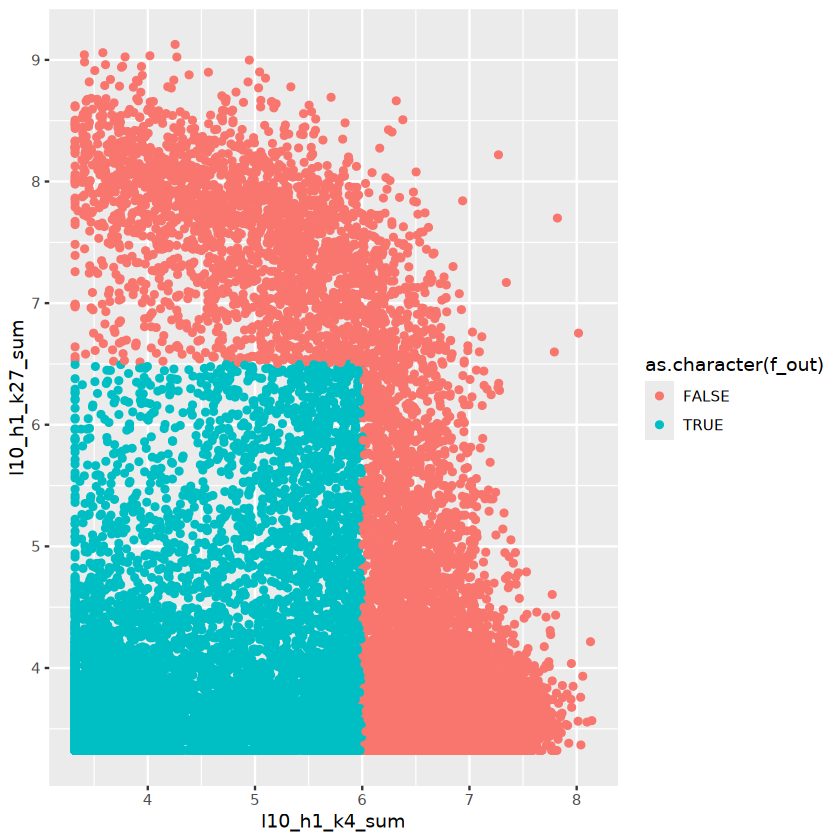

In [16]:
cgd%>% ggplot(aes(x=l10_h1_k4_sum ,y= l10_h1_k27_sum,col=as.character(f_out)))+ geom_point()

In [15]:
#saveRDS(cgd,'data/cgd_for_IQhg19.rds')